In [2]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
from sklearn import linear_model

In [3]:
data = pd.read_csv('CPU_Benchmark_Dataset.csv')

In [ ]:
data.head(10)

### mean and std

In [4]:
print(f"""
core mean: {data.CORES.mean()}
score mean: {data.BENCHMARK_SCORE.mean()}
core std: {data.CORES.std()}
score std: {data.BENCHMARK_SCORE.std()}""")


core mean: 8.913333333333334
score mean: 15240.033333333333
core std: 5.9230705526323435
score std: 6030.528323878922


Text(0, 0.5, 'BENCHMARK SCORE')

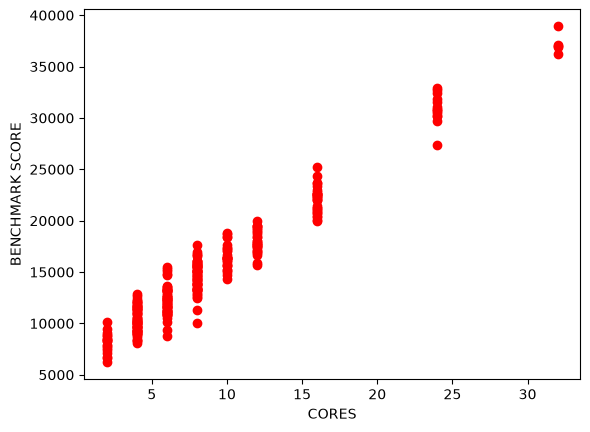

In [5]:
plt.scatter(data.CORES,data.BENCHMARK_SCORE,color= 'red')
plt.xlabel('CORES')
plt.ylabel('BENCHMARK SCORE')

In [6]:
mask = np.random.rand(len(data)) < 0.8
train = data[mask]
test = data[~mask]
print(f"percentage= train: {(len(train)/len(data))*100} test: {(len(test)/len(data))*100}")

percentage= train: 80.33333333333333 test: 19.666666666666664


In [7]:
benchmarkAI = linear_model.LinearRegression()
train_X = np.asanyarray(train[['CORES']])
train_Y = np.asanyarray(train[['BENCHMARK_SCORE']])

In [8]:
benchmarkAI.fit(train_X,train_Y)
print(f"coefficient: {benchmarkAI.coef_} intercept: {benchmarkAI.intercept_}")

coefficient: [[993.6762999]] intercept: [6395.39496437]


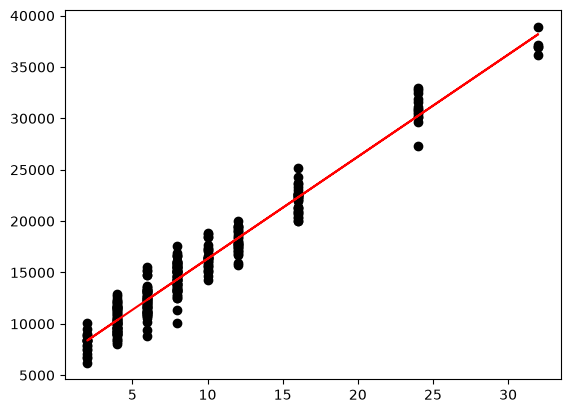

In [ ]:
plt.scatter(data.CORES,data.BENCHMARK_SCORE,color= 'black')
plt.plot(train.CORES,benchmarkAI.coef_[0][0] * train_X + benchmarkAI.intercept_[0] , 'r-')

In [10]:
test_X = np.asanyarray(test[['CORES']])
test_Y = np.asanyarray(test[['BENCHMARK_SCORE']])

In [11]:
test_Y_out = benchmarkAI.predict(test_X)

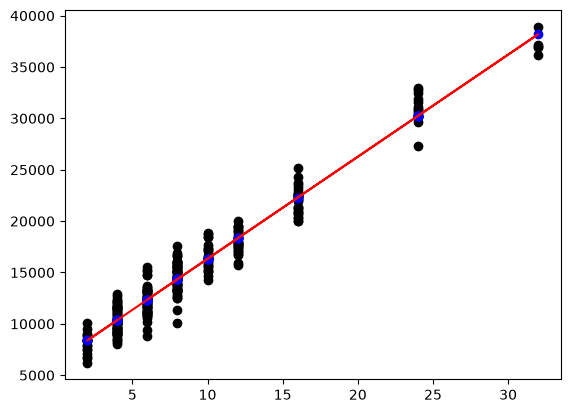

In [ ]:
plt.scatter(data.CORES,data.BENCHMARK_SCORE,color= 'black')
plt.scatter(test_X,test_Y_out,color= 'blue')
plt.plot(train.CORES,benchmarkAI.coef_[0][0] * train_X + benchmarkAI.intercept_[0] , 'r-')

In [13]:
absolute_error =  np.abs(test_Y - test_Y_out)
mae = np.mean(absolute_error)
squared = np.square(test_Y - test_Y_out)
mse = np.mean(squared)

print(f"""mae: {mae}
mse: {mse}""")

mae: 1140.156034227712
mse: 2040511.6701515538


In [30]:
cores = 5
bench = benchmarkAI.coef_[0][0] * cores + benchmarkAI.intercept_[0]
print(f"benchmark: {bench}")

benchmark: 11363.776463867036
